<a href="https://colab.research.google.com/github/Fafichka/analyser/blob/main/Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ тональности русскоязычных твитов

Этот проект решает задачу бинарной классификации твитов (положительный твит или негативный). В проекте используется датасет Ю. Рубцовой rutweetcorp.

## 1. Импорт библиотек и загрузка данных

Загружаем датасет с сайта kaggle:

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maximsuvorov/rutweetcorp")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rutweetcorp' dataset.
Path to dataset files: /kaggle/input/rutweetcorp


Устанавливаем и импортируекм библиотеки:

In [2]:
!pip install wordcloud
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.2 MB/s eta 0:00:00


In [3]:
import seaborn as sns
import pandas as pd
import nltk
import pymorphy3
import sklearn
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

Загружаем стоп-слова:

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 2. Анализ данных

Читаем датасет, собираем единый датафрейм из положительных и негавтивных твитов и перемешиваем:

In [5]:
pos_f=os.path.join(path, "positive.csv")
neg_f=os.path.join(path, "negative.csv")
df_pos=pd.read_csv(pos_f, sep=',', header=None)
df_neg=pd.read_csv(neg_f, sep=',', header=None)
df_pos=df_pos[[3]].rename(columns={3:'text'})
df_neg=df_neg[[3]].rename(columns={3:'text'})
df_pos['label']=1
df_neg['label']=0
df=pd.concat([df_pos, df_neg], ignore_index=True)
df=df.sample(frac=1, random_state=42).reset_index(drop=True)
display(df)

/tmp/ipykernel_17763/1801281548.py:3: DtypeWarning: Columns (0,1,4,5,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pos=pd.read_csv(pos_f, sep=',', header=None)
/tmp/ipykernel_17763/1801281548.py:4: DtypeWarning: Columns (0,1,4,5,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_neg=pd.read_csv(neg_f, sep=',', header=None)


,text,label
0,"@Im_from_MAPC я не выспался, отсюда негатив:-)...",1
1,"""@IkerAkinfeev: @EstonianPirate вам утром воск...",0
2,"Новый Год? Не, не слыхал... С утра ЖКХ спасал,...",0
3,блиииин я в шокеее так то..ну как так то?:(,0
4,"Андре, спасибо за заскок!)\nТы сделал эти выхо...",1
...,...,...
226831,"ты ещё и овен как и я,как же я тебя терпеть т...",0
226832,"Нда, непонятно почему в сети так мало материал...",1
226833,блииин!..ВЧЕРА ШЕЮ РЕЗКО ПОВЕРНУЛА...теперь си...,0
226834,@vengeance96661 я кушать скоро пойду. а так ни...,0


Визуализируем самые часто встречающиеся слова с помощью wordcloud:

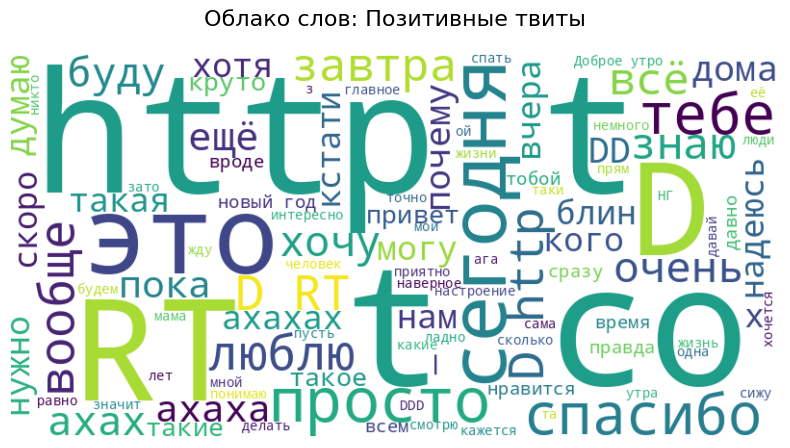

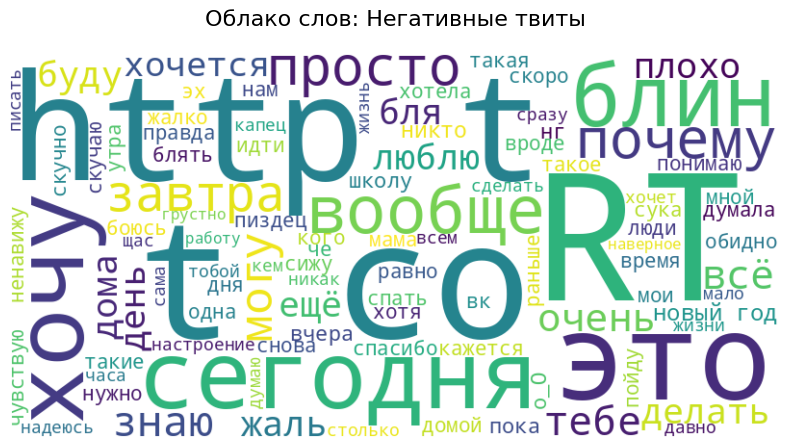

In [6]:
stop_words = set(stopwords.words('russian'))

def plot_wordcloud(text_series, title):
    text = " ".join(text_series.astype(str))

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=stop_words,
                          colormap='viridis',
                          max_words=100).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, pad=20)
    plt.show()

plot_wordcloud(df[df['label'] == 1]['text'], 'Облако слов: Позитивные твиты')
plot_wordcloud(df[df['label'] == 0]['text'], 'Облако слов: Негативные твиты')

Видим, что очень много мусора сейчас находится в датасете. Исправим это.

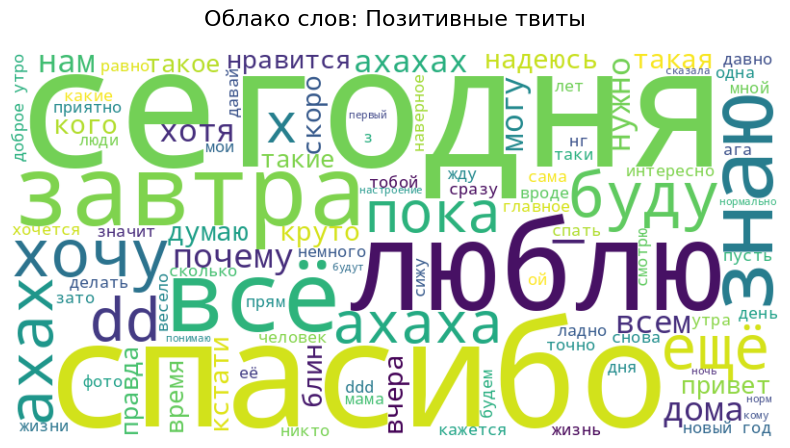

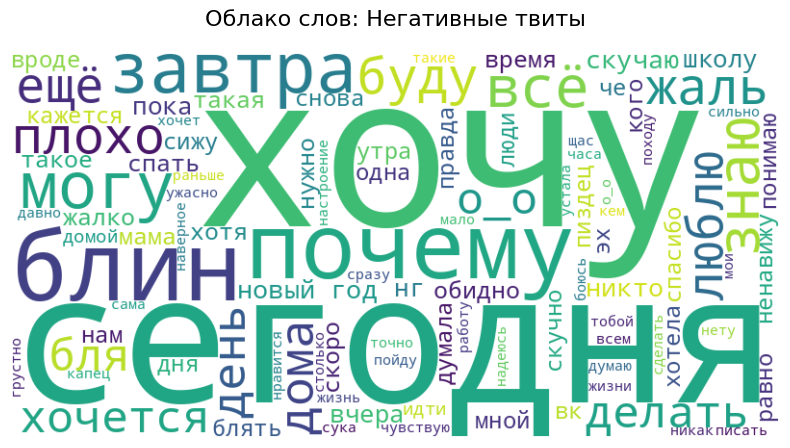

In [7]:
stop_words = set(stopwords.words('russian'))
stop_words.update(['rt', 'http', 'https', 'co', 't', 'это', 'просто', 'd', 'очень', 'та', 'вообще', 'тебе'])
def plot_wordcloud(text_series, title):
    text = " ".join(text_series.astype(str)).lower()

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=stop_words,
                          colormap='viridis',
                          max_words=100).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, pad=20)
    plt.show()

plot_wordcloud(df[df['label'] == 1]['text'], 'Облако слов: Позитивные твиты')
plot_wordcloud(df[df['label'] == 0]['text'], 'Облако слов: Негативные твиты')

Уже стало лучше. Теперь посмотрим на распределение длин твитов. Может быть негативные твиты длинее и можно ввести дополнительный признак, чтобы модель лучше обучилась?

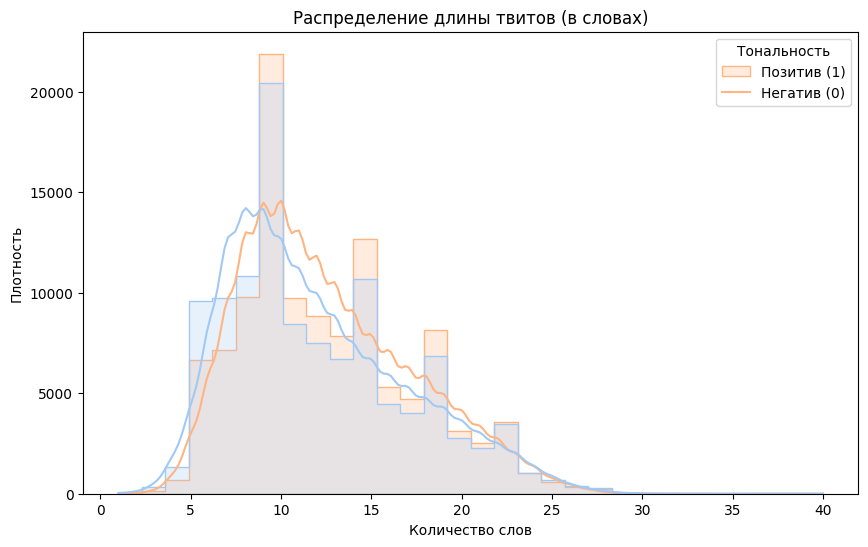

In [8]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='label',
             bins=30, kde=True, palette='pastel',
             element='step')

plt.title('Распределение длины твитов (в словах)')
plt.xlabel('Количество слов')
plt.ylabel('Плотность')
plt.legend(title='Тональность', labels=['Позитив (1)', 'Негатив (0)'])
plt.show()

Особой разницы в длине твита нет. Положительные и негативные твиты примерно одинаковы по длине: где-то 7-15 слов.

## 3. Предобработка текста

В твитах содержится очень много мусора, который будет путать модель и не принесет никаких полезных данных. Также может случиться так, что будет пользователь, которого часто тегают в положительных твитах. Тогда модель может посчитать, что это как-то влияет на эмоциональную окраску твита, хотя это не так.

Лемматизируем текст с помощью pymorhy, а также почистим его от ссылок, тегов, смайликов и английских слов:

In [9]:
morph = pymorphy3.MorphAnalyzer()
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+', '', text)

    text = re.sub(r'[^а-яё]', ' ', text)
    words = text.split()
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            normal_form = morph.parse(word)[0].normal_form
            cleaned_words.append(normal_form)
    return " ".join(cleaned_words)

df['cleaned_text'] = df['text'].apply(clean_text)

display(df[['text', 'cleaned_text']].head(10))

,text,cleaned_text
0,"@Im_from_MAPC я не выспался, отсюда негатив:-)...",выспаться отсюда негатив занятый
1,"""@IkerAkinfeev: @EstonianPirate вам утром воск...",утром воскресение заняться нечего б снеговик п...
2,"Новый Год? Не, не слыхал... С утра ЖКХ спасал,...",новый год слыхать утро жкх спасать счас санато...
3,блиииин я в шокеее так то..ну как так то?:(,блиииина шокеий
4,"Андре, спасибо за заскок!)\nТы сделал эти выхо...",андре спасибо заскок сделать выходной
5,@Zchtec @YakovGR это очень хорошо! Нас чуть ме...,маленький кто грустно
6,RT @PolinaBalenko: Ее все чтоли смотрят?:D htt...,чтоль смотреть
7,Благодаря моему пальцу нам дали еще время для ...,благодаря мой палец мы дать время катание
8,RT @bykatrin_: @DarinaSarbash дарюшечка моя :...,дарюшечка соскучиться
9,@kopteva1709 @JulJulianapai да уж девочки))))ю...,девочка юмор женский чёрный чёрный однако


Посмотрим на то, как теперь выглядит наше облако слов:

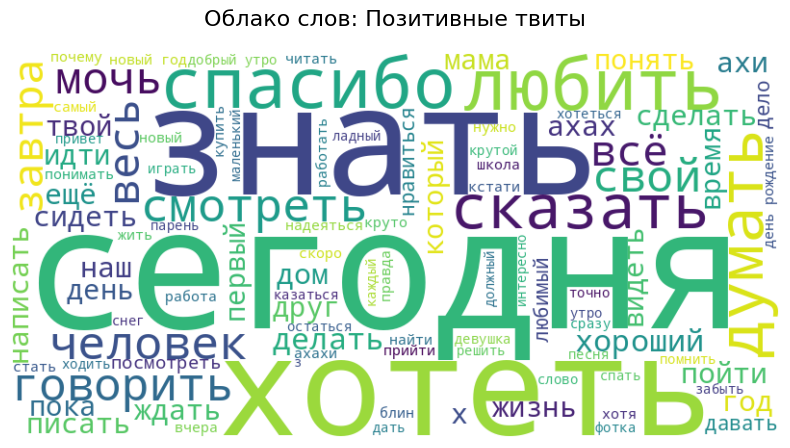

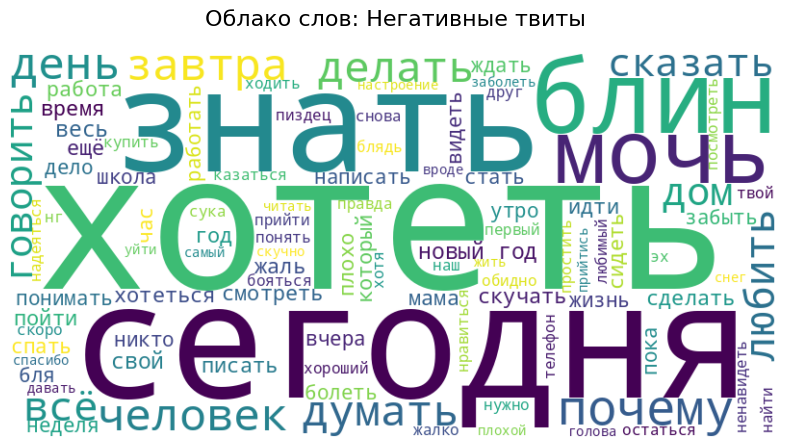

In [11]:
plot_wordcloud(df[df['label'] == 1]['cleaned_text'], 'Облако слов: Позитивные твиты')
plot_wordcloud(df[df['label'] == 0]['cleaned_text'], 'Облако слов: Негативные твиты')

## 4. Векторизация и обучение модели

Теперь обучим логистическую регрессию для определения положительный твит или отрицательный:

In [12]:
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=25000,  ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

В качестве векторизатора был выбран TF-IDF, поскольку он быстрый, а также позволяет вычленить те самые слова, которые являются маркерами негативного или позитивного твита.

Алгоритм логистической регрессии был выбран поскольку это позволяет получить не просто ответ, а вероятность принадлежности классу. Это позволяет анализировать ошибки модели. Также можно узнать, какие слова при принятии решения имеют наибольший вес.

## 5. Оценка модели

Оценим модель:

--- Отчет о классификации ---
              precision    recall  f1-score   support

 Негатив (0)       0.74      0.69      0.71     22404
 Позитив (1)       0.71      0.76      0.74     22964

    accuracy                           0.72     45368
   macro avg       0.72      0.72      0.72     45368
weighted avg       0.72      0.72      0.72     45368



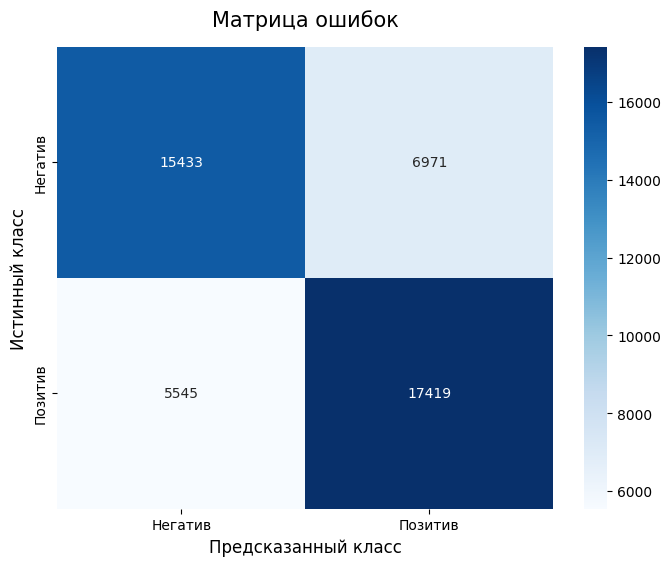

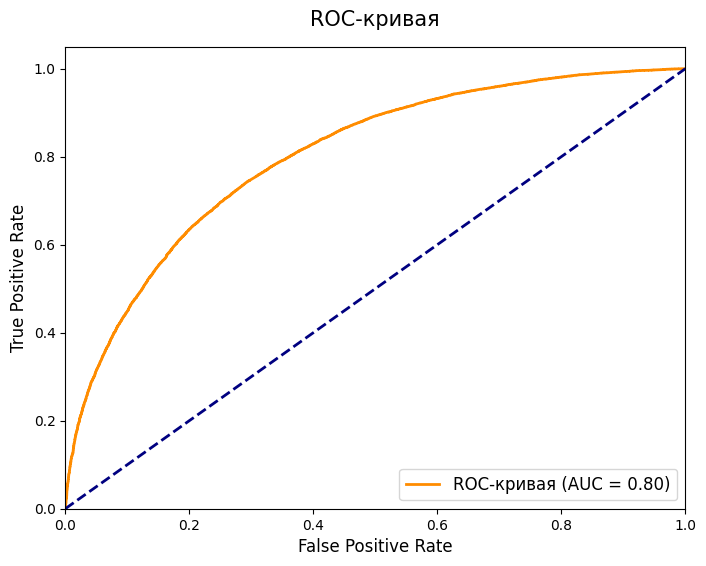

In [13]:
y_pred = model.predict(X_test_tfidf)

y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

print("--- Отчет о классификации ---")
print(classification_report(y_test, y_pred, target_names=['Негатив (0)', 'Позитив (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Негатив', 'Позитив'],
            yticklabels=['Негатив', 'Позитив'])
plt.title('Матрица ошибок', fontsize=15, pad=15)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая', fontsize=15, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.show()

ROC-AUC показывает достаточно высокие результаты (0.8). Эту оценку лучше использовать, поскольку она показывает общую способность модели отличать позитивные твиты от негативных на всех порогах. Это делает оценку более устойчивой.

## 6. Выводы

Посмотрим, какие слова модель считает показателями негативного/позитивного твита:

In [17]:
features=vectorizer.get_feature_names_out()
coe=model.coef_[0]
words=pd.DataFrame({'Слово':features, 'Вес':coe})
top_pos=words.sort_values(by='Вес', ascending=False).head(10)
top_neg=words.sort_values(by='Вес', ascending=True).head(10)
print('Топ 10 слов, являющихся показателями положительного твита')
display(top_pos.reset_index(drop=True))
print('Топ 10 слов, являющихся показателями негативного твита')
display(top_neg.reset_index(drop=True))

Топ 10 слов, являющихся показателями положительного твита


,Слово,Вес
0,ахах,4.113186
1,ахахи,3.999929
2,приятно,3.933965
3,хах,3.754118
4,ахи,3.752049
5,забавно,3.590667
6,нужный ёлка,3.508743
7,обожать,3.385173
8,смех,3.363063
9,довольный,3.305905


Топ 10 слов, являющихся показателями негативного твита


,Слово,Вес
0,обидно,-6.109241
1,жаль,-5.613531
2,грустно,-5.438812
3,печально,-5.382464
4,жалко,-4.935832
5,печаль,-4.774268
6,жизньболь,-4.432196
7,сожаление,-4.406643
8,ужасно,-4.302617
9,заболеть,-4.100629


В ходе данного проекта была решена задача бинарной классификации тональности русскоязычных твитов на датасете rutweetcorp.

**Основные результаты:**
1. Связка логистической регрессии и TF-IDF показала себя как сильный бейзлайн
2. Модель достигла ROC-AUC на уровне 0.8 и F1-score для миноритарного класса на уровне 0.71. Это показывает нам то, что алгоритм хорошо справляется с предсказанием принадлежности к классу.
3. Анализ весов логистической регрессии подтвердил что модель действительно нашла правильные закономерности. Для положительных твитов это такие слова, как "приятно", "забавно", "обожать", а для негативных твитов это "обидно", "ужасно", "грустно".

**Трудности:**
1. Большое количество мусора, сленга и опечаток
2. Много сарказма и специфического юмора, который модели сложно уловить

**Дальнейшие пути развития:**
1. Воспользоваться трансформерами (дообучить какую-либо модель)
2. Использовать векторные представления слов для захвата семантической близости (fasttext)

##7. Веб-приложение

Дальнейший код нужен для сохранения весов модели и создания скрипта для веб-приложения.

In [14]:
import pickle

with open('logreg_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Модель и векторизатор успешно сохранены!")

Модель и векторизатор успешно сохранены!


In [15]:
%%writefile app.py
import streamlit as st
import pickle
import re
import pymorphy3
from nltk.corpus import stopwords
nltk.download('stopwords')
@st.cache_resource
def load_models():
    with open('logreg_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    morph = pymorphy3.MorphAnalyzer()
    stop_words = set(stopwords.words('russian'))
    stop_words.update(['rt', 'http', 'https', 'co', 't', 'это'])
    return model, vectorizer, morph, stop_words

model, vectorizer, morph, stop_words = load_models()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+', '', text)
    text = re.sub(r'[^а-яё]', ' ', text)
    words = text.split()
    cleaned_words = [morph.parse(w)[0].normal_form for w in words if w not in stop_words]
    return " ".join(cleaned_words)

st.title("🎭 Анализ тональности твитов")
st.write("Введите любой текст, и модель определит, позитивный он или негативный!")

user_input = st.text_area("Ваш текст:", height=100)

if st.button("Проанализировать"):
    if user_input.strip() == "":
        st.warning("Пожалуйста, введите текст.")
    else:
        cleaned = clean_text(user_input)
        vectorized = vectorizer.transform([cleaned])
        prediction = model.predict(vectorized)[0]
        probability = model.predict_proba(vectorized)[0]

        st.subheader("Результат:")
        if prediction == 1:
            st.success(f"😊 Позитивный текст (Уверенность: {probability[1]:.1%})")
        else:
            st.error(f"😠 Негативный текст (Уверенность: {probability[0]:.1%})")

        with st.expander("Посмотреть, как модель видит текст после очистки:"):
            st.code(cleaned)

Writing app.py


In [ ]:
!pip install streamlit -q
!npm install localtunnel -g -q

import urllib
print("Пароль для входа на сайт:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

!streamlit run app.py & npx localtunnel --port 8501